# Final experiments (the last GPU run)

This is the complete remaining experiment set, built once. It reuses everything already finished (backbones, ε choice).

| Part | What | Why a reviewer needs it | GTX 1070 time |
|---|---|---|---|
| A | 4 methods × 4 training-data sizes (10%, 25%, 50%, 100%), per-model temperature scaling | Does hesitation help most when labels are scarce? Proper calibration protocol | ~9–10 h |
| B | Second architecture (WRN-16-4): 3 backbones + the 4-method study | The effect is not ResNet-specific | ~7 h |

**Record of the run:** every line printed is also appended, with a timestamp, to `runs\logs\final_run_log.txt`, and the executed notebook (with all outputs) is saved as `Final_Experiments_executed.ipynb`. Each study folder also keeps `args.json`, `results.jsonl` and one checkpoint per fold.

**Resumable** exactly like before: if anything stops, open this notebook and choose **Run All**. Finished work is skipped.

Fold 0 is skipped everywhere (it was used to choose ε). Methods: soft labels, constant softening, shuffled hesitation, hesitation-softened.
10% of each training fold is held out to fit a per-model temperature.

In [1]:
import os, sys, json, glob, importlib
ROOT = os.path.abspath(os.getcwd())
assert os.path.isdir(os.path.join(ROOT, "src")), "Open this notebook from inside the code_kit folder"
sys.path.insert(0, os.path.join(ROOT, "src"))
DATA, SOURCE = os.path.join(ROOT, "data"), "torchvision"
RUNS, FIGS = os.path.join(ROOT, "runs"), os.path.join(ROOT, "figs", "final")
os.makedirs(FIGS, exist_ok=True)
HUMAN_TABLE = os.path.join(RUNS, "human_image_table.csv")
SEEDS, BATCH, WORKERS = [0, 1, 2], 128, 2
EPOCHS_FULL, EPOCHS_BACKBONE = 30, 100
METHODS = ["soft", "ls", "hes_shuf", "hes"]
FRACS = [1.0, 0.5, 0.25, 0.1]
CALIB = 0.1
OOD = ["svhn", "cifar100"]
EPS = json.load(open(os.path.join(RUNS, "chosen_eps.json")))["eps_max"]
BACKBONE_R18 = os.path.join(RUNS, "backbone_resnet18_s{seed}.pt")
BACKBONE_WRN = os.path.join(RUNS, "backbone_wrn16_4_s{seed}.pt")
# ---- permanent run record: everything printed below is also appended to runs\logs\final_run_log.txt ----
import datetime
LOGDIR = os.path.join(RUNS, "logs"); os.makedirs(LOGDIR, exist_ok=True)
LOGFILE = os.path.join(LOGDIR, "final_run_log.txt")
class _Tee:
    def __init__(self, stream, path): self.stream, self.fh = stream, open(path, "a", encoding="utf-8", buffering=1)
    def write(self, s):
        self.stream.write(s)
        if s.strip(): self.fh.write(f"[{datetime.datetime.now():%Y-%m-%d %H:%M:%S}] {s.rstrip()}\n")
        return len(s)
    def flush(self): self.stream.flush(); self.fh.flush()
    def __getattr__(self, k): return getattr(self.stream, k)
if not hasattr(sys.stdout, "fh"):
    sys.stdout = _Tee(sys.stdout, LOGFILE)
print("=== session started; log file:", LOGFILE)
import train_backbone, finetune_human, figures_results, figstyle
for m in (train_backbone, finetune_human, figures_results, figstyle): importlib.reload(m)

def study(backbone, frac, out):
    finetune_human.main(["--backbone", backbone, "--human_table", HUMAN_TABLE, "--mode", "full",
        "--methods", *METHODS, "--epochs", str(EPOCHS_FULL), "--bs", str(BATCH), "--seeds", *map(str, SEEDS),
        "--eps_max", str(EPS), "--frac", str(frac), "--calib", str(CALIB), "--skip_folds", "0",
        "--ood", *OOD, "--source", SOURCE, "--root", DATA, "--workers", str(WORKERS), "--out", out])
print("ready | eps_max =", EPS)

=== session started; log file: C:\Users\D67\Downloads\Unanimous_but_Hesitant_full_package_1\Unanimous_but_Hesitant\code_kit\runs\logs\final_run_log.txt


ready | eps_max = 0.03


## Part A: data efficiency with per-model temperature scaling (ResNet-18)

In [2]:
A_RUNS = {f: os.path.join(RUNS, f"final_r18_frac{f}") for f in FRACS}
for f, out in A_RUNS.items():
    print(f"=== ResNet-18, {int(f*100)}% of training data ===", flush=True)
    study(BACKBONE_R18, f, out)

=== ResNet-18, 100% of training data ===


seed 0 soft      fold 1 acc 0.9445 hNLL 0.3148 ECE 0.0199 rhoU 0.360 387s


seed 0 soft      fold 2 acc 0.9385 hNLL 0.3295 ECE 0.0207 rhoU 0.429 393s


seed 0 soft      fold 3 acc 0.9400 hNLL 0.3165 ECE 0.0284 rhoU 0.424 377s


seed 0 soft      fold 4 acc 0.9610 hNLL 0.2863 ECE 0.0306 rhoU 0.440 401s


...

seed 2 hes       fold 1 acc 0.9380 hNLL 0.3382 ECE 0.0359 rhoU 0.341 204s


seed 2 hes       fold 2 acc 0.9285 hNLL 0.3604 ECE 0.0352 rhoU 0.377 203s


seed 2 hes       fold 3 acc 0.9270 hNLL 0.3541 ECE 0.0396 rhoU 0.363 204s


seed 2 hes       fold 4 acc 0.9450 hNLL 0.3236 ECE 0.0363 rhoU 0.441 203s


all folds complete -> C:\Users\D67\Downloads\Unanimous_but_Hesitant_full_package_1\Unanimous_but_Hesitant\code_kit\runs\final_r18_frac0.1


## Part B: second architecture (WRN-16-4)

In [3]:
for seed in SEEDS:
    print(f"--- WRN-16-4 backbone seed {seed} ---", flush=True)
    train_backbone.main(["--arch", "wrn16_4", "--epochs", str(EPOCHS_BACKBONE), "--bs", str(BATCH), "--seed", str(seed),
                         "--source", SOURCE, "--root", DATA, "--workers", str(WORKERS), "--out", BACKBONE_WRN.format(seed=seed)])
B_RUN = os.path.join(RUNS, "final_wrn16_4_frac1.0")
study(BACKBONE_WRN, 1.0, B_RUN)

--- WRN-16-4 backbone seed 0 ---


ep   1/100 loss 1.3273 acc 0.5180 41s


ep   2/100 loss 0.8975 acc 0.6828 35s


ep   3/100 loss 0.7238 acc 0.7454 36s


ep   4/100 loss 0.6270 acc 0.7835 36s


...

seed 2 hes       fold 1 acc 0.9470 hNLL 0.3192 ECE 0.0424 rhoU 0.333 335s


seed 2 hes       fold 2 acc 0.9445 hNLL 0.3287 ECE 0.0451 rhoU 0.397 336s


seed 2 hes       fold 3 acc 0.9335 hNLL 0.3354 ECE 0.0398 rhoU 0.431 337s


seed 2 hes       fold 4 acc 0.9445 hNLL 0.3201 ECE 0.0403 rhoU 0.416 337s


all folds complete -> C:\Users\D67\Downloads\Unanimous_but_Hesitant_full_package_1\Unanimous_but_Hesitant\code_kit\runs\final_wrn16_4_frac1.0


## Results: tables and figures (all temperature-scaled per model)

  setting method  ref                 metric  delta_better   ci95  wins  p_wilcoxon  ref_mean
ResNet-18    hes soft              Human NLL        0.0018 0.0013  9/12      0.0122    0.3376
ResNet-18    hes soft                    ECE       -0.0019 0.0021  3/12      0.0771    0.0131
ResNet-18    hes soft        ECE under shift       -0.0024 0.0026  5/12      0.0640    0.2202
ResNet-18    hes soft  Human NLL under shift        0.0119 0.0145  8/12      0.1294    1.7855
ResNet-18    hes soft Hesitation alignment ρ        0.0209 0.0051 12/12      0.0005    0.4110
ResNet-18    hes soft               Accuracy        0.0006 0.0015  6/12      0.6118    0.9455
 WRN-16-4    hes soft              Human NLL        0.0012 0.0015  8/12      0.1294    0.3667
 WRN-16-4    hes soft                    ECE       -0.0009 0.0024  5/12      0.4238    0.0113
 WRN-16-4    hes soft        ECE under shift       -0.0097 0.0035  1/12      0.0010    0.2120
 WRN-16-4    hes soft  Human NLL under shift       -0.0592 0

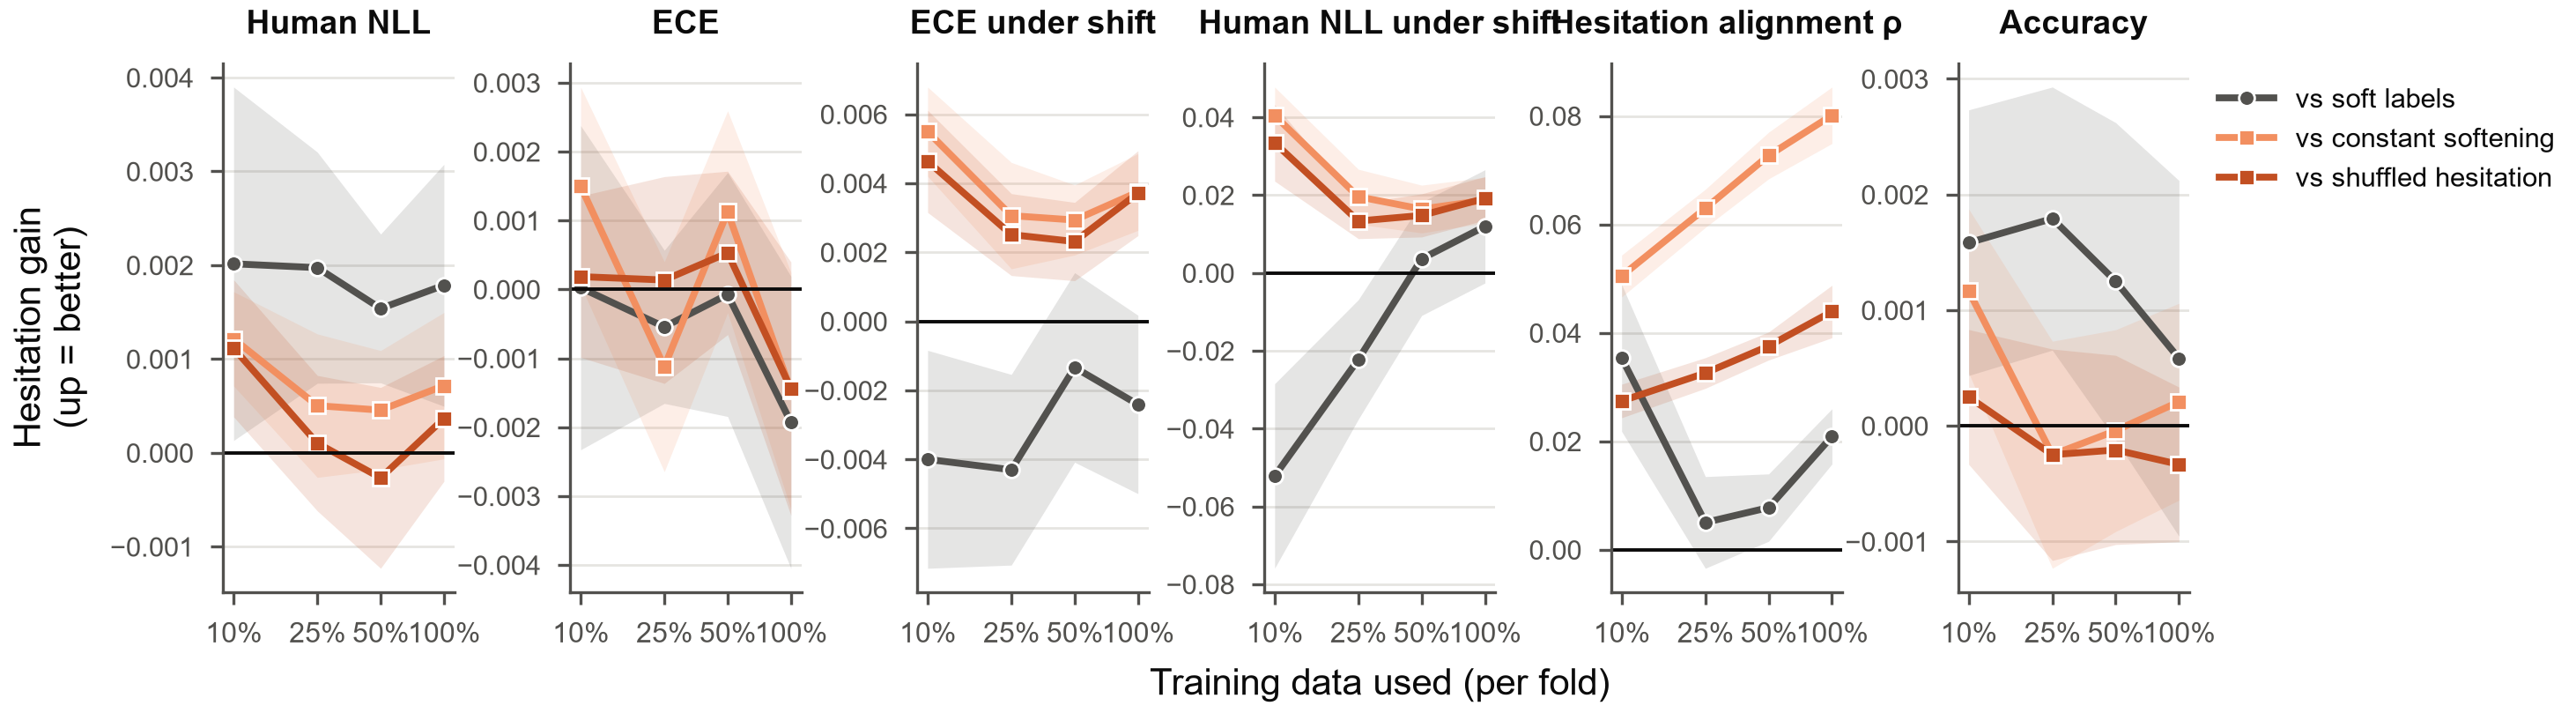


ALL DONE. Send the folder runs\final_* results.jsonl files and figs\final.


In [4]:
from IPython.display import Image, display
import pandas as pd
figstyle.use()
tA = figures_results.fig10_data_efficiency(A_RUNS, FIGS)
tB = figures_results.paired_table({"ResNet-18": A_RUNS[1.0], "WRN-16-4": B_RUN})
tA.to_csv(os.path.join(FIGS, "paired_data_efficiency.csv"), index=False)
tB.to_csv(os.path.join(FIGS, "paired_architectures.csv"), index=False)
pd.set_option("display.width", 200)
print(tB[tB.ref == "soft"].round(4).to_string(index=False))
display(Image(os.path.join(FIGS, "fig10_data_efficiency.png"), width=950))
print("\nALL DONE. Send the folder runs\\final_* results.jsonl files and figs\\final.")

## Progress check

In [5]:
for f in FRACS:
    d = os.path.join(RUNS, f"final_r18_frac{f}")
    print(f"A {int(f*100):3d}%:", len(glob.glob(os.path.join(d, "folds", "*.npz"))), "/ 48 folds", "(done)" if os.path.exists(os.path.join(d, "DONE")) else "")
for s in SEEDS:
    b = BACKBONE_WRN.format(seed=s)
    print(f"B backbone s{s}:", "done" if os.path.exists(b) else ("in progress" if os.path.exists(b + ".resume") else "not started"))
d = os.path.join(RUNS, "final_wrn16_4_frac1.0")
print("B study:", len(glob.glob(os.path.join(d, "folds", "*.npz"))), "/ 48 folds", "(done)" if os.path.exists(os.path.join(d, "DONE")) else "")

A 100%: 48 / 48 folds (done)
A  50%: 48 / 48 folds (done)
A  25%: 48 / 48 folds (done)
A  10%: 48 / 48 folds (done)
B backbone s0: done
B backbone s1: done
B backbone s2: done
B study: 48 / 48 folds (done)
